In [1]:
# Import required libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')



In [2]:
username = "root"
password = "*******"
host = "localhost"
port = "3306"
database = "superstore_db"

engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}"
)

df = pd.read_sql("SELECT * FROM superstore_campaign", engine)

df.head()


,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain,Age,Total_Spend,Total_Purchases
0,0,1985,Graduation,Married,70951.0,0,0,2013-04-05,66,239,...,1,3,4,9,1,0,0,41,1198,17
1,1,1961,Graduation,Single,57091.0,0,0,2014-06-15,0,464,...,1,7,3,7,5,1,0,65,577,18
2,9,1975,Master,Single,46098.0,1,1,2012-08-18,86,57,...,4,3,2,2,8,0,0,51,120,11
3,13,1947,PhD,Widowed,25358.0,0,1,2013-07-22,57,19,...,2,1,0,3,6,0,0,79,32,6
4,17,1971,PhD,Married,60491.0,0,1,2013-06-09,81,637,...,4,6,11,7,5,0,0,55,1028,28


In [3]:
df.shape

(2240, 25)

In [4]:
df.dtypes

Id                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProducts          int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
Response                 int64
Complain                 int64
Age                      int64
Total_Spend              int64
Total_Purchases          int64
dtype: object

In [5]:
df.isnull().sum()


Id                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProducts         0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Response                0
Complain                0
Age                     0
Total_Spend             0
Total_Purchases         0
dtype: int64

In [6]:
df.duplicated().sum()


np.int64(0)

In [7]:
df['Education'].nunique()


4

In [8]:
df['Total_Spend'].sum()


np.int64(1356988)

# Data Cleaning 

In [9]:
df['Income'].fillna(df['Income'].median(), inplace=True)


In [10]:
df.head()

,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain,Age,Total_Spend,Total_Purchases
0,0,1985,Graduation,Married,70951.0,0,0,2013-04-05,66,239,...,1,3,4,9,1,0,0,41,1198,17
1,1,1961,Graduation,Single,57091.0,0,0,2014-06-15,0,464,...,1,7,3,7,5,1,0,65,577,18
2,9,1975,Master,Single,46098.0,1,1,2012-08-18,86,57,...,4,3,2,2,8,0,0,51,120,11
3,13,1947,PhD,Widowed,25358.0,0,1,2013-07-22,57,19,...,2,1,0,3,6,0,0,79,32,6
4,17,1971,PhD,Married,60491.0,0,1,2013-06-09,81,637,...,4,6,11,7,5,0,0,55,1028,28


In [11]:
# Spending columns
spend_cols = [
    'MntWines','MntFruits','MntMeatProducts',
    'MntFishProducts','MntSweetProducts','MntGoldProducts'
]

df[spend_cols] = df[spend_cols].fillna(0)


# Feature Engineering:

In [12]:
# Compute Age from Year_Birth.
current_year = datetime.now().year
df['Age'] = current_year - df['Year_Birth']
df[['Year_Birth','Age']].head(10)



,Year_Birth,Age
0,1985,41
1,1961,65
2,1975,51
3,1947,79
4,1971,55
5,1965,61
6,1976,50
7,1960,66
8,1958,68
9,1987,39


In [13]:
# Calculate customer tenure from Dt_Customer.

df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])
df['Tenure'] = (datetime.now() - df['Dt_Customer']).dt.days / 365


In [14]:
# Compute Total Spend by summing all Mnt* columns.
df['Total_Spend'] = df[spend_cols].sum(axis=1)


In [15]:
# Determine Category_Breadth by counting how many product categories have non-zero spend. 
df['Category_Breadth'] = (df[spend_cols] > 0).sum(axis=1)
df[['Category_Breadth','Id']].head()

,Category_Breadth,Id
0,6,0
1,5,1
2,3,9
3,3,13
4,6,17


In [16]:
# Derive engagement metrics from the Num* columns, such as total purchases or ratios of web vs. store purchases. 
df['Total_Purchases'] = (
    df['NumWebPurchases'] +
    df['NumCatalogPurchases'] +
    df['NumStorePurchases']
)


In [17]:
# web purchase ratio
df['Web_Ratio'] = df['NumWebPurchases'] / df['Total_Purchases']

#  Exploratory Data Analysis (EDA)

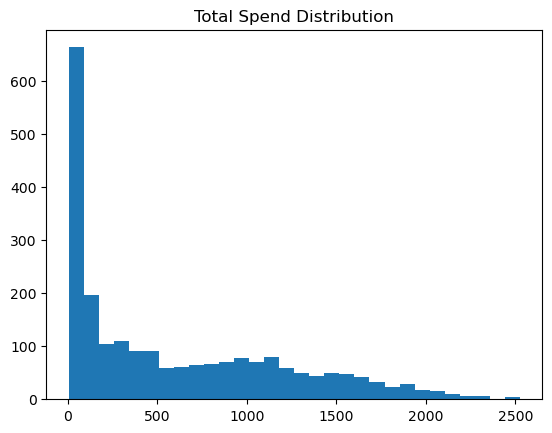

In [18]:
# Histogram (Total Spend)
plt.hist(df['Total_Spend'], bins=30)
plt.title("Total Spend Distribution")
plt.show()


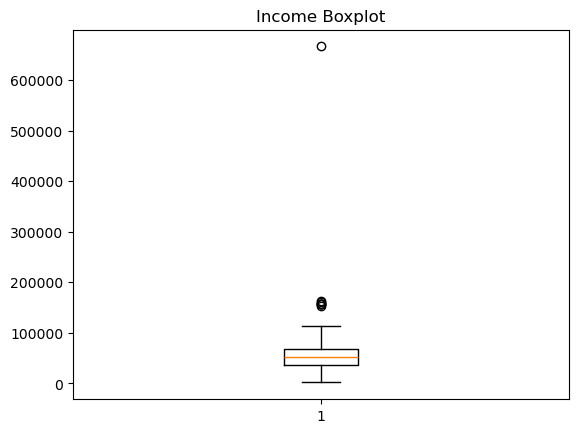

In [19]:
# Boxplot (Income)

plt.boxplot(df['Income'])
plt.title("Income Boxplot")
plt.show()


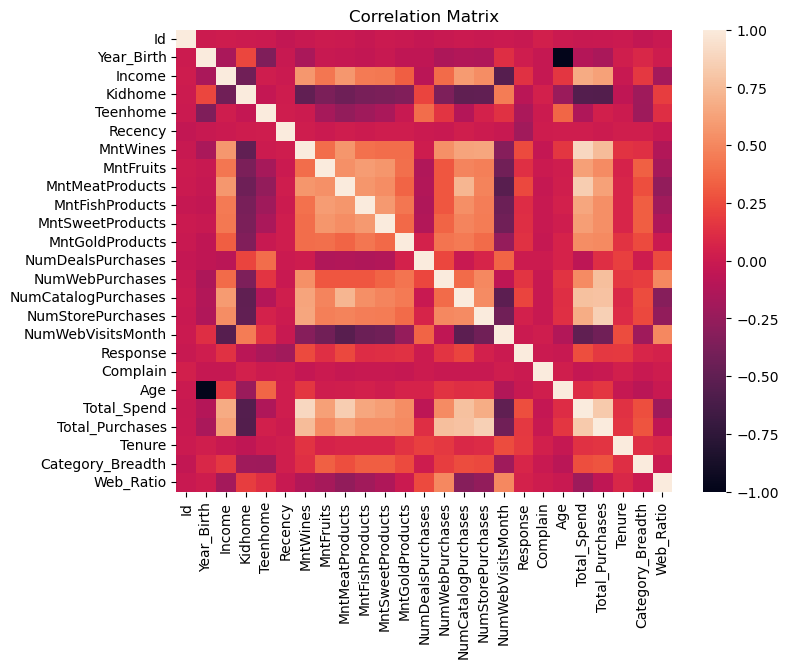

In [20]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=False)
plt.title("Correlation Matrix")
plt.show()


In [21]:
# High Spending Segment
high_spenders = df[df['Total_Spend'] > df['Total_Spend'].median()]
high_spenders.shape


(1119, 28)

In [22]:
# Under-Penetrated Segment
df[(df['Income'] > df['Income'].median()) &
   (df['Total_Spend'] < df['Total_Spend'].median())]


,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,Response,Complain,Age,Total_Spend,Total_Purchases,Tenure,Category_Breadth,Web_Ratio
10,48,1964,Graduation,Married,55761.0,0,1,2014-04-24,97,136,...,3,6,0,0,62,184,8,11.846575,5,0.500000
14,73,1953,PhD,Single,51411.0,1,2,2013-05-26,81,14,...,3,5,0,0,73,18,3,12.758904,3,0.000000
23,125,1958,Basic,Married,53083.0,1,1,2013-05-15,65,215,...,5,7,0,0,68,271,11,12.789041,5,0.454545
30,176,1980,Basic,Single,67506.0,0,1,2014-02-01,73,90,...,6,3,0,0,46,331,11,12.071233,6,0.363636
48,246,1965,Graduation,Married,66480.0,1,1,2014-05-31,71,199,...,7,4,0,0,61,312,12,11.745205,6,0.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2205,11004,1893,Basic,Single,60182.0,0,1,2014-05-17,23,8,...,2,4,0,0,133,22,3,11.783562,4,0.333333
2212,11039,1975,Graduation,Married,51948.0,0,1,2013-09-17,51,82,...,4,5,0,0,51,311,11,12.446575,6,0.454545
2223,11096,1952,Basic,Married,57247.0,0,1,2013-08-08,50,99,...,7,2,0,0,74,232,10,12.556164,6,0.200000
2224,11100,1972,Graduation,Divorced,51813.0,1,1,2013-11-04,37,51,...,3,7,0,0,54,63,5,12.315068,5,0.400000


In [23]:
df.head()


,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,Response,Complain,Age,Total_Spend,Total_Purchases,Tenure,Category_Breadth,Web_Ratio
0,0,1985,Graduation,Married,70951.0,0,0,2013-04-05,66,239,...,9,1,0,0,41,1198,16,12.898630,6,0.187500
1,1,1961,Graduation,Single,57091.0,0,0,2014-06-15,0,464,...,7,5,1,0,65,577,17,11.704110,5,0.411765
2,9,1975,Master,Single,46098.0,1,1,2012-08-18,86,57,...,2,8,0,0,51,120,7,13.528767,3,0.428571
3,13,1947,PhD,Widowed,25358.0,0,1,2013-07-22,57,19,...,3,6,0,0,79,32,4,12.602740,3,0.250000
4,17,1971,PhD,Married,60491.0,0,1,2013-06-09,81,637,...,7,5,0,0,55,1028,24,12.720548,6,0.250000


# Statistical Analysis 

In [24]:
#Group comparisons
df.groupby('Kidhome')['Total_Spend'].mean()


Kidhome
0    901.260634
1    205.434928
2    145.250000
Name: Total_Spend, dtype: float64

In [25]:
from scipy.stats import ttest_ind

with_kids = df[(df['Kidhome'] > 0) | (df['Teenhome'] > 0)]['Total_Spend']
no_kids = df[(df['Kidhome'] == 0) & (df['Teenhome'] == 0)]['Total_Spend']

t_stat, p_value = ttest_ind(with_kids, no_kids)

print("Average Spend (With Kids):", with_kids.mean())
print("Average Spend (No Kids):", no_kids.mean())
print("P-value:", p_value)


Average Spend (With Kids): 406.57990012484396
Average Spend (No Kids): 1106.0297805642633
P-value: 2.023752068671191e-158


In [26]:
# Acceptance Rate Comparison
with_kids_resp = df[(df['Kidhome'] > 0) | (df['Teenhome'] > 0)]['Response']
no_kids_resp = df[(df['Kidhome'] == 0) & (df['Teenhome'] == 0)]['Response']

t_stat_resp, p_value_resp = ttest_ind(with_kids_resp, no_kids_resp)

print("Acceptance Rate (With Kids):", with_kids_resp.mean())
print("Acceptance Rate (No Kids):", no_kids_resp.mean())
print("P-value (Acceptance):", p_value_resp)


Acceptance Rate (With Kids): 0.10299625468164794
Acceptance Rate (No Kids): 0.26489028213166144
P-value (Acceptance): 1.0424367047639332e-22


## Variance Analysis (ANOVA)

In [27]:
#Education vs Total Spend (ANOVA)
df.groupby('Education')['Total_Spend'].mean()


Education
Basic         409.385214
Graduation    619.898846
Master        611.781081
PhD           672.409465
Name: Total_Spend, dtype: float64

In [28]:
from scipy.stats import f_oneway

groups = [group['Total_Spend'].values 
          for name, group in df.groupby('Education')]

f_stat, p_value = f_oneway(*groups)

print("ANOVA p-value:", p_value)


ANOVA p-value: 1.8361393210251286e-07


In [29]:
# Relationship test (Chi-square)

# Chi-Square Test (Education vs Response)
from scipy.stats import chi2_contingency

table = pd.crosstab(df['Education'], df['Response'])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square p-value:", p)


Chi-square p-value: 8.840050548990529e-05


In [30]:
# Marital Status vs Response
table_marital = pd.crosstab(df['Marital_Status'], df['Response'])

chi2, p, dof, expected = chi2_contingency(table_marital)

print("Chi-square p-value (Marital):", p)


Chi-square p-value (Marital): 6.164467480815522e-11


In [31]:
# Income Bracket ANOVA
df['Income_Bracket'] = pd.qcut(df['Income'], 3, 
                               labels=['Low','Medium','High'])

groups_income = [group['Total_Spend'].values 
                 for name, group in df.groupby('Income_Bracket')]

from scipy.stats import f_oneway
f_oneway(*groups_income)


F_onewayResult(statistic=np.float64(2155.9017791524607), pvalue=np.float64(0.0))

# Modelling

In [32]:
#Model Objective
#Predicting Gold Membership Acceptance (Response)

#The goal is to build a classification model to predict whether a customer will accept the Gold Membership offer.
    

In [33]:
#Feature Selection
# Selection of Key Predictive Variables
# Selecting important features
features = ['Income', 'Age', 'Total_Spend', 
            'NumWebPurchases', 'Recency']
X = df[features]
y = df['Response']



In [34]:

# Data Splitting Strategy
# Train–Test Split (70% Training, 30% Testing)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

In [35]:
# Model Development
# Random Forest Classification Model
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [36]:
# MODEL 1 — Original Random Forest

# from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report

y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Model Accuracy: 85.86%

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       575
           1       0.52      0.26      0.34        97

    accuracy                           0.86       672
   macro avg       0.70      0.61      0.63       672
weighted avg       0.83      0.86      0.84       672



In [37]:
# MODEL 2 — Class Weight Balanced

rf_balanced = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_balanced.fit(X_train, y_train)
y_pred_balanced = rf_balanced.predict(X_test)

print("=== MODEL 2: Class Weight Balanced ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_balanced)*100:.2f}%")
print(classification_report(y_test, y_pred_balanced))


=== MODEL 2: Class Weight Balanced ===
Accuracy: 85.71%
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       575
           1       0.51      0.23      0.31        97

    accuracy                           0.86       672
   macro avg       0.70      0.60      0.62       672
weighted avg       0.83      0.86      0.83       672



In [38]:
# MODEL 3 — SMOTE (Best for Marketing)

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("=== Before SMOTE ===")
print(f"Class 0: {sum(y_train==0)}, Class 1: {sum(y_train==1)}")
print("=== After SMOTE ===")
print(f"Class 0: {sum(y_train_smote==0)}, Class 1: {sum(y_train_smote==1)}")

rf_smote = RandomForestClassifier(random_state=42)
rf_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = rf_smote.predict(X_test)

print("\n=== MODEL 3: SMOTE ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_smote)*100:.2f}%")
print(classification_report(y_test, y_pred_smote))



=== Before SMOTE ===
Class 0: 1331, Class 1: 237
=== After SMOTE ===
Class 0: 1331, Class 1: 1331

=== MODEL 3: SMOTE ===
Accuracy: 77.23%
              precision    recall  f1-score   support

           0       0.90      0.83      0.86       575
           1       0.30      0.44      0.36        97

    accuracy                           0.77       672
   macro avg       0.60      0.64      0.61       672
weighted avg       0.81      0.77      0.79       672



In [39]:
# FINAL COMPARISON

print("=== FINAL COMPARISON ===")
print("Model 1 Original      — Buyers found: 26 out of 100")
print("Model 2 Class Weight  — Buyers found: 23 out of 100")
print("Model 3 SMOTE         — Buyers found: 44 out of 100")
print("\nBest for marketing = SMOTE")
print("Reason: Limited budget allows for more actual buyers")

=== FINAL COMPARISON ===
Model 1 Original      — Buyers found: 26 out of 100
Model 2 Class Weight  — Buyers found: 23 out of 100
Model 3 SMOTE         — Buyers found: 44 out of 100

Best for marketing = SMOTE
Reason: Limited budget allows for more actual buyers


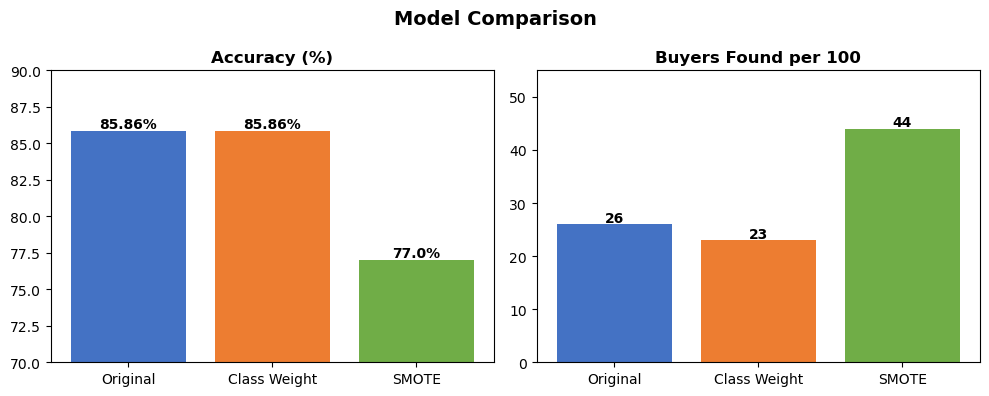

In [46]:
import matplotlib.pyplot as plt

# Data
models = ['Original', 'Class Weight', 'SMOTE']
accuracy = [85.86, 85.86, 77.0]
recall   = [26, 23, 44]
colors   = ['#4472C4', '#ED7D31', '#70AD47']

# Two charts side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Chart 1 — Accuracy
ax1.bar(models, accuracy, color=colors)
ax1.set_title('Accuracy (%)', fontweight='bold')
ax1.set_ylim(70, 90)
for i, v in enumerate(accuracy):
    ax1.text(i, v + 0.2, f'{v}%', ha='center', fontweight='bold')

# Chart 2 — Buyers Found
ax2.bar(models, recall, color=colors)
ax2.set_title('Buyers Found per 100', fontweight='bold')
ax2.set_ylim(0, 55)
for i, v in enumerate(recall):
    ax2.text(i, v + 0.5, str(v), ha='center', fontweight='bold')

plt.suptitle('Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

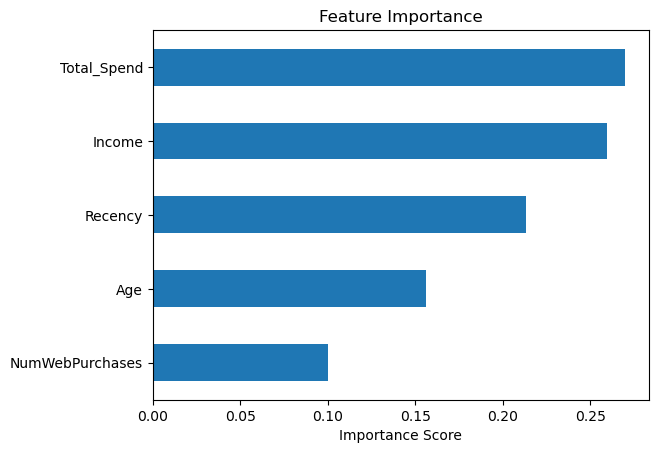

In [40]:
# Feature Importance Analysis
# Identifying Key Drivers of Membership Acceptance
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    rf_model.feature_importances_, 
    index=features
).sort_values()

importance.plot(kind='barh')
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.show()

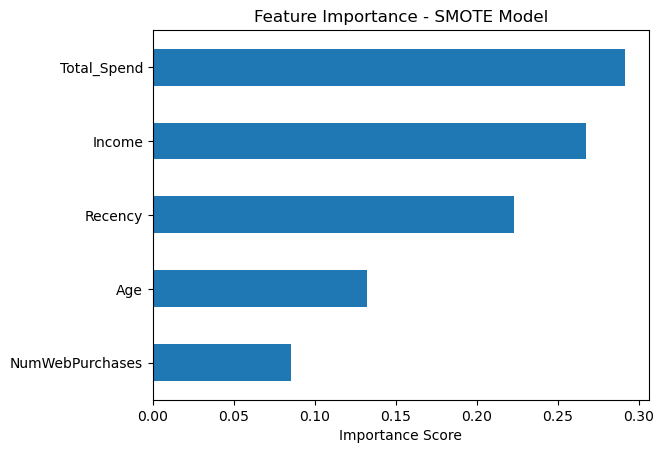

In [41]:
# Feature Importance — SMOTE Model
importance_smote = pd.Series(
    rf_smote.feature_importances_,
    index=features
).sort_values()
importance_smote.plot(kind='barh')
plt.title('Feature Importance - SMOTE Model')
plt.xlabel('Importance Score')
plt.show()

In [47]:
df.to_sql(
    name='superstore_campaign_clean',
    con=engine,
    if_exists='append',  
    index=False
)


2240